# Parity Si 2D

**Purpose.** Reproduce the named radiative-transfer experiment with its original computational workflow.

**Distinction.** This notebook is the canonical study; existing code, parameters, outputs, and execution order are unchanged.


# 2D four-quadrant parity discrete ordinates

Sparse traditional solver for the five-equation odd-even formulation. The model coefficients, source, and inflow data come from `src/configuration/rte_2d_settings.py`.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np

SRC_ROOT = Path('/home/sheny-y23/rte_oe/src')
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

from configuration.rte_2d_settings import get_config
from scipy.special import roots_legendre
from scipy.sparse.linalg import LinearOperator, gmres
from time import perf_counter

/home/sheny-y23/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## Odd-even sparse solver

This notebook contains all assembly and solution steps for the $j_1,r_1,j_2,r_2$ system.

In [2]:
# First-quadrant matrix-free GMRES solver. f[...,0:4] corresponds to
# (+,+), (-,+), (-,-), (+,-), respectively.
def solve_parity_si_2d(config, num_angles=None, tol=1e-11, max_iter=500, report_every=50, gmres_restart=100):
    started=perf_counter(); nx,ny=map(int,config.model.grid_sizes[:2]); na=int(num_angles or config.model.num_quads); eps=float(config.model.knudsen_number)
    xmin,xmax=map(float,config.mesh['domain']['x']); ymin,ymax=map(float,config.mesh['domain']['y']); dx=(xmax-xmin)/nx; dy=(ymax-ymin)/ny
    x=xmin+(np.arange(nx)+.5)*dx; y=ymin+(np.arange(ny)+.5)*dy; X,Y=np.meshgrid(x,y,indexing='ij')
    z,w=roots_legendre(na); theta=.25*np.pi*(z+1); w=.5*w; mu=np.cos(theta); eta=np.sin(theta)
    ss=np.broadcast_to(np.asarray(config.model.coeff['scattering'](X,Y),float),(nx,ny)); sa=np.broadcast_to(np.asarray(config.model.coeff['absorption'](X,Y),float),(nx,ny)); st=ss+eps**2*sa
    angles=np.concatenate((theta,np.pi-theta,np.pi+theta,2*np.pi-theta)); dirs=np.stack((np.cos(angles),np.sin(angles)),axis=1); nang=4*na
    src=np.empty((nx,ny,nang))
    for a,t in enumerate(angles): src[:,:,a]=np.broadcast_to(np.asarray(config.model.source(X,Y,t),float),(nx,ny))
    f=np.ones((nx,ny,nang)); b=config.model.bdy_cond
    def rho(F): return .25*np.tensordot(F.reshape(nx,ny,4,na).sum(axis=2),w,axes=([-1],[0]))
    # AP central transport difference.  In the diffusive limit its angular
    # average is the centred discretisation of -div((2 sigma_s)^(-1) grad rho),
    # whereas the former one-sided sweep introduced an O(h/eps) artificial diffusion.
    vx,vy=dirs[:,0],dirs[:,1]
    # Diagonal transport stabilization.  The alpha*F terms cancel at the
    # fixed point, but suppress high-frequency divergence on fine grids.
    transport_alpha=eps*(np.abs(vx)/dx+np.abs(vy)/dy)
    def centred_x(F):
        out=np.empty_like(F); out[1:-1]=(F[2:]-F[:-2])/(2*dx)
        for a, speed in enumerate(vx):
            if speed > 0:
                left_ghost=2*np.asarray(b['f_l'](y),float)-F[0,:,a]
                right_ghost=3*F[-1,:,a]-3*F[-2,:,a]+F[-3,:,a]
            else:
                left_ghost=3*F[0,:,a]-3*F[1,:,a]+F[2,:,a]
                right_ghost=2*np.asarray(b['f_r'](y),float)-F[-1,:,a]
            out[0,:,a]=(F[1,:,a]-left_ghost)/(2*dx)
            out[-1,:,a]=(right_ghost-F[-2,:,a])/(2*dx)
        return out
    def centred_y(F):
        out=np.empty_like(F); out[:,1:-1]=(F[:,2:]-F[:,:-2])/(2*dy)
        for a, speed in enumerate(vy):
            if speed > 0:
                bottom_ghost=2*np.asarray(b['f_b'](x),float)-F[:,0,a]
                top_ghost=3*F[:,-1,a]-3*F[:,-2,a]+F[:,-3,a]
            else:
                bottom_ghost=3*F[:,0,a]-3*F[:,1,a]+F[:,2,a]
                top_ghost=2*np.asarray(b['f_t'](x),float)-F[:,-1,a]
            out[:,0,a]=(F[:,1,a]-bottom_ghost)/(2*dy)
            out[:,-1,a]=(top_ghost-F[:,-2,a])/(2*dy)
        return out
    def sweep(F,r):
        q=ss[:,:,None]*r[:,:,None]+eps**2*src
        transport=eps*(vx[None,None,:]*centred_x(F)+vy[None,None,:]*centred_y(F))
        G=(q+transport_alpha[None,None,:]*F-transport)/(st[:,:,None]+transport_alpha[None,None,:])
        return G
    zero=np.zeros_like(f); g0=sweep(zero, rho(zero))
    def matvec(vector):
        state=vector.reshape(nx,ny,nang)
        return (state-(sweep(state, rho(state))-g0)).ravel()
    operator=LinearOperator((f.size,f.size), matvec=matvec, dtype=float)
    history=[]
    def callback(residual):
        value=float(residual) if np.isscalar(residual) else float(np.linalg.norm(residual))
        history.append(value)
        if len(history)==1 or len(history)%report_every==0:
            print(f'GMRES iteration {len(history):6d}: residual = {value:.6e}')
    rhs=g0.ravel()
    solution, info=gmres(operator, rhs, x0=f.ravel(), rtol=tol, atol=0.0, restart=gmres_restart, maxiter=max_iter, callback=callback, callback_type='pr_norm')
    absolute_residual=float(np.linalg.norm(matvec(solution)-rhs))
    rhs_norm=float(np.linalg.norm(rhs))
    relative_residual=absolute_residual/rhs_norm if rhs_norm else absolute_residual
    f=solution.reshape(nx,ny,nang)
    fp=f.reshape(nx,ny,4,na); r1=.5*(fp[:,:,3]+fp[:,:,1]); j1=(fp[:,:,3]-fp[:,:,1])/(2*eps); r2=.5*(fp[:,:,0]+fp[:,:,2]); j2=(fp[:,:,0]-fp[:,:,2])/(2*eps)
    return dict(x=x,y=y,theta=theta,weights=w,r1=r1,j1=j1,r2=r2,j2=j2,rho=rho(f),iterations=len(history),converged=info==0,absolute_residual=absolute_residual,relative_residual=relative_residual,runtime_seconds=perf_counter()-started)

In [3]:
rte_config = get_config()
domain = dict(rte_config.mesh['domain'])
strides = rte_config.mesh['strides']
kn = float(rte_config.model.knudsen_number)
coeff_fns = rte_config.model.coeff
source_fn = rte_config.model.source
bdy_value = rte_config.model.bdy_cond
num_quads = int(rte_config.model.num_quads)
grid_sizes = tuple(map(int, rte_config.model.grid_sizes))

# The parity solver uses the physical and numerical data directly from
# src/configuration/rte_2d_settings.py; do not override source or boundary data here.
num_angles = num_quads

print('epsilon:', kn)
print('domain:', domain)
print('grid_sizes:', grid_sizes)
print('first-quadrant angular ordinates:', num_angles)

epsilon: 0.001
domain: {'theta': (0.0, 6.283185307179586), 'x': (-1.0, 1.0), 'y': (-1.0, 1.0)}
grid_sizes: (128, 128, 64)
first-quadrant angular ordinates: 16


In [4]:
# Kn=1e-4 scan: use no DSA correction; tested positive values slowed convergence.
result = solve_parity_si_2d(
    rte_config,
    num_angles=num_angles,
    report_every=100,
    max_iter=50,
    tol=1e-9,
    gmres_restart=100,
)
print(f"GMRES inner iterations: {result['iterations']}")
print(f"converged: {result['converged']}")
print(f"true relative residual: {result['relative_residual']:.6e}")
print(f"runtime: {result['runtime_seconds']:.3f} s")

GMRES iteration      1: residual = 5.599234e+00
GMRES iteration    100: residual = 5.696165e-03
GMRES iteration    200: residual = 1.965293e-03
GMRES iteration    300: residual = 1.205155e-03
GMRES iteration    400: residual = 7.468465e-04
GMRES iteration    500: residual = 4.673902e-04
GMRES iteration    600: residual = 2.924534e-04
GMRES iteration    700: residual = 1.837464e-04
GMRES iteration    800: residual = 1.153445e-04
GMRES iteration    900: residual = 7.262225e-05
GMRES iteration   1000: residual = 4.566816e-05
GMRES iteration   1100: residual = 2.885700e-05
GMRES iteration   1200: residual = 1.828217e-05
GMRES iteration   1300: residual = 1.158561e-05
GMRES iteration   1400: residual = 7.342157e-06
GMRES iteration   1500: residual = 4.651695e-06
GMRES iteration   1600: residual = 2.925761e-06
GMRES iteration   1700: residual = 1.843579e-06
GMRES iteration   1800: residual = 1.167633e-06
GMRES iteration   1900: residual = 7.394611e-07
GMRES iteration   2000: residual = 4.685

In [5]:
# # Exact solution f(x, y, theta) = exp(-x - y).
# X, Y = np.meshgrid(result['x'], result['y'], indexing='ij')
# f_exact = np.exp(-X - Y)[:, :, None]
# w = result['weights'][None, None, :]
# f_quadrants = (
#     result['r1'] + eps * result['j1'], result['r1'] - eps * result['j1'],
#     result['r2'] + eps * result['j2'], result['r2'] - eps * result['j2'],
# )
# f_error_sq = sum(np.sum(w * (f - f_exact)**2) for f in f_quadrants)
# f_exact_sq = 4.0 * np.sum(w * f_exact**2)
# rel_l2_f = np.sqrt(f_error_sq / f_exact_sq)
# rel_l2_rho = np.linalg.norm(result['rho'] - f_exact[:, :, 0]) / np.linalg.norm(f_exact[:, :, 0])
# print(f'Relative L2 error of f: {rel_l2_f:.6e}')
# print(f'Relative L2 error of rho: {rel_l2_rho:.6e}')
# print(f'End-to-end cost: {result["runtime_seconds"]:.3f} s')

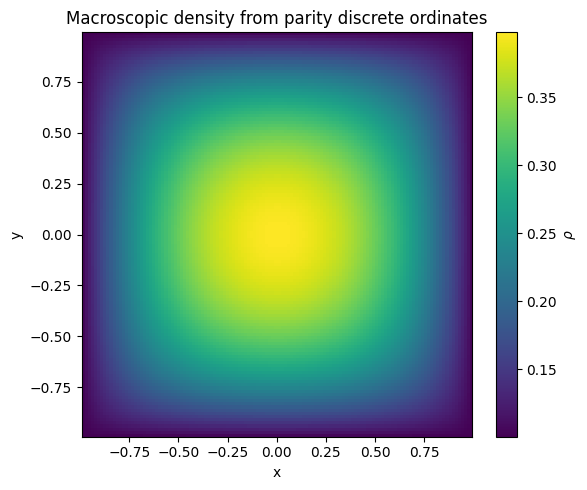

In [6]:
extent = (result['x'][0], result['x'][-1], result['y'][0], result['y'][-1])
plt.figure(figsize=(6, 5))
plt.imshow(result['rho'].T, origin='lower', extent=extent, aspect='auto', cmap='viridis')
plt.colorbar(label=r'$\rho$')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Macroscopic density from parity discrete ordinates')
plt.tight_layout()

In [7]:
eps = kn
f_xi_minus_eta = result['r1'] + eps * result['j1']
f_minus_xi_eta = result['r1'] - eps * result['j1']
f_xi_eta = result['r2'] + eps * result['j2']
f_minus_xi_minus_eta = result['r2'] - eps * result['j2']

print('Reconstructed f arrays:', f_xi_minus_eta.shape)
print('Angular range (first quadrant):', result['theta'].min(), result['theta'].max())

Reconstructed f arrays: (128, 128, 16)
Angular range (first quadrant): 0.008324486191288298 1.5624718406036082


In [8]:
# # 3D visualization and numerical-solution evaluation.
# # Prefer the mplot3d package installed with the active Matplotlib version.
# from pathlib import Path
# import matplotlib
# import mpl_toolkits
# local_mpl_toolkits = Path(matplotlib.__file__).parent.parent / 'mpl_toolkits'
# if str(local_mpl_toolkits) not in mpl_toolkits.__path__:
#     mpl_toolkits.__path__.insert(0, str(local_mpl_toolkits))
# from mpl_toolkits.mplot3d import Axes3D
# matplotlib.projections.projection_registry.register(Axes3D)

# X_3d, Y_3d = np.meshgrid(result['x'], result['y'], indexing='ij')
# rho_numerical = result['rho']
# rho_exact = np.exp(-X_3d - Y_3d)
# rho_abs_error = np.abs(rho_numerical - rho_exact)

# fig = plt.figure(figsize=(16, 5), constrained_layout=True)
# for index, (field, title, cmap, zlabel) in enumerate((
#     (rho_numerical, r'Numerical $\rho(x,y)$', 'viridis', r'$\rho$'),
#     (rho_exact, r'Exact $\rho(x,y)=e^{-x-y}$', 'viridis', r'$\rho$'),
#     (rho_abs_error, r'Absolute error $|\rho-\rho_{exact}|$', 'magma', r'$|e|$'),
# )):
#     ax = fig.add_subplot(1, 3, index + 1, projection='3d')
#     surface = ax.plot_surface(X_3d, Y_3d, field, cmap=cmap, linewidth=0, antialiased=True)
#     ax.set(xlabel='x', ylabel='y', zlabel=zlabel, title=title)
#     fig.colorbar(surface, ax=ax, shrink=0.7, pad=0.08)
# plt.show()
# plt.close(fig)

# # Evaluation view 1: spatial relative-error map.
# rho_relative_error = rho_abs_error / np.maximum(np.abs(rho_exact), np.finfo(float).eps)
# fig, ax = plt.subplots(figsize=(6.5, 5), constrained_layout=True)
# error_map = ax.contourf(X_3d, Y_3d, rho_relative_error, levels=100, cmap='magma')
# ax.set(xlabel='x', ylabel='y', title=r'Pointwise relative error $|\rho-\rho_{exact}|/|\rho_{exact}|$')
# fig.colorbar(error_map, ax=ax, label='relative error')
# plt.show()
# plt.close(fig)

# # Evaluation view 2: diagonal profile and pointwise error.
# diagonal = np.arange(min(rho_numerical.shape))
# diagonal_x = result['x'][diagonal]
# rho_numerical_diagonal = rho_numerical[diagonal, diagonal]
# rho_exact_diagonal = rho_exact[diagonal, diagonal]
# fig, (ax_solution, ax_error) = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
# ax_solution.plot(diagonal_x, rho_exact_diagonal, label='exact', linewidth=2)
# ax_solution.plot(diagonal_x, rho_numerical_diagonal, '--', label='numerical', linewidth=2)
# ax_solution.set(xlabel=r'$x=y$', ylabel=r'$\rho$', title='Diagonal solution profile')
# ax_solution.legend()
# ax_error.semilogy(diagonal_x, np.abs(rho_numerical_diagonal-rho_exact_diagonal))
# ax_error.set(xlabel=r'$x=y$', ylabel='absolute error', title='Diagonal pointwise error')
# plt.show()
# plt.close(fig)

In [9]:
# error = np.abs(result["rho"] - rho_exact)

# width = 2
# boundary = np.zeros_like(error, dtype=bool)
# boundary[:width, :] = True
# boundary[-width:, :] = True
# boundary[:, :width] = True
# boundary[:, -width:] = True
# interior = ~boundary

# print("boundary max:", error[boundary].max())
# print("interior max:", error[interior].max())
# print("boundary RMS:", np.sqrt(np.mean(error[boundary] ** 2)))
# print("interior RMS:", np.sqrt(np.mean(error[interior] ** 2)))
# print(
#     "boundary L2 contribution:",
#     np.sum(error[boundary] ** 2) / np.sum(error ** 2),
# )

In [10]:
if not result['converged']:
    raise RuntimeError('GMRES did not converge; refusing to save an unconverged reference solution.')

kn = float(rte_config.model.knudsen_number)
mesh_x = result['x']
mesh_y = result['y']
tensor_f = np.concatenate(
    (f_xi_eta, f_minus_xi_eta, f_minus_xi_minus_eta, f_xi_minus_eta),
    axis=-1,
)
avg_f = result['rho']

output_path = Path(f"../data/rte2d_ex5_ref_{kn:.1e}.npz")
output_path.parent.mkdir(parents=True, exist_ok=True)
np.savez(
    output_path,
    mesh_x=mesh_x,
    mesh_y=mesh_y,
    f=tensor_f,
    rho=avg_f,
)
print(f'Saved reference solution to {output_path}')
kn


Saved reference solution to ../data/rte2d_ex5_ref_1.0e-03.npz


0.001